# Introduction to LSTM for Agriculture Applications

**Long Short-Term Memory (LSTM)** networks are a special type of recurrent neural network (RNN) designed to model **sequential data**. Unlike traditional neural networks, LSTMs can **remember information over long sequences**, making them ideal for tasks where past data influences future outcomes.

In agriculture, many key variables—such as **crop yields, rainfall, soil moisture, and market prices**—follow time-dependent patterns. LSTMs are particularly well-suited for:

- **Crop Yield Forecasting:** Predicting future yield based on historical yields, weather patterns, and soil conditions.  
- **Environmental Monitoring:** Modeling soil moisture, temperature, and rainfall trends to optimize irrigation or planting schedules.  
- **Market Price Prediction:** Forecasting future produce prices to help farmers make better economic decisions.

## Key Features of LSTM

1. **Memory Cells:** LSTM units contain cells that can store information over long periods.  
2. **Gates:** LSTM uses three gates—**input, forget, and output gates**—to control how information flows in and out of memory.  
3. **Sequence Learning:** By processing data sequentially, LSTM can learn patterns that depend on both recent and distant events in the data.

## Why LSTM for Agriculture?

Agriculture data is often **time-dependent** and **non-linear**, influenced by multiple environmental and human factors. Classical regression or simple machine learning models may fail to capture complex temporal dependencies. LSTMs, however, can:

- Handle **long-term dependencies** (e.g., a drought two years ago affecting current crop yield).  
- Learn **non-linear patterns** in sequential data.  
- Provide **accurate forecasts** that can guide farmers and policymakers.

## Example Workflow

1. Collect historical agricultural data (yield, rainfall, temperature).  
2. Preprocess data into sequences for LSTM input (e.g., past 3–5 years of yield).  
3. Train LSTM to predict the next time step (e.g., next year’s yield).  
4. Evaluate model performance and refine for better predictions.  

> In this notebook, we will demonstrate **how to implement an LSTM model to forecast crop yield**, using a real-world agriculture dataset. Students will learn how to preprocess sequential data, build LSTM models, and evaluate predictions, all in Python using TensorFlow/Keras.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('crop_yield.csv')
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [3]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

In [4]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [6]:
scaler = StandardScaler()

In [7]:
df['Crop_Year_scaled'] = scaler.fit_transform(df[['Crop_Year']])
df['Area_scaled'] = scaler.fit_transform(df[['Area']])
df['Production_scaled'] = scaler.fit_transform(df[['Production']])
df['Annual_Rainfall_scaled'] = scaler.fit_transform(df[['Annual_Rainfall']])
df['Fertilizer_scaled'] = scaler.fit_transform(df[['Fertilizer']])
df['Pesticide_scaled'] = scaler.fit_transform(df[['Pesticide']])
df['Yield_scaled'] = scaler.fit_transform(df[['Yield']])

In [8]:
df.isnull().sum()

Crop                      0
Crop_Year                 0
Season                    0
State                     0
Area                      0
Production                0
Annual_Rainfall           0
Fertilizer                0
Pesticide                 0
Yield                     0
Crop_Year_scaled          0
Area_scaled               0
Production_scaled         0
Annual_Rainfall_scaled    0
Fertilizer_scaled         0
Pesticide_scaled          0
Yield_scaled              0
dtype: int64

In [10]:
df.nunique()

Crop                         55
Crop_Year                    24
Season                        6
State                        30
Area                      13644
Production                14016
Annual_Rainfall             634
Fertilizer                18598
Pesticide                 17405
Yield                     13551
Crop_Year_scaled             24
Area_scaled               13644
Production_scaled         14016
Annual_Rainfall_scaled      634
Fertilizer_scaled         18598
Pesticide_scaled          17405
Yield_scaled              13551
dtype: int64

In [11]:
label_encoder = LabelEncoder()
df['crop_encoded'] = label_encoder.fit_transform(df['Crop'])
df['season_encoded'] = label_encoder.fit_transform(df['Season'])
df['state_encoded'] = label_encoder.fit_transform(df['State'])

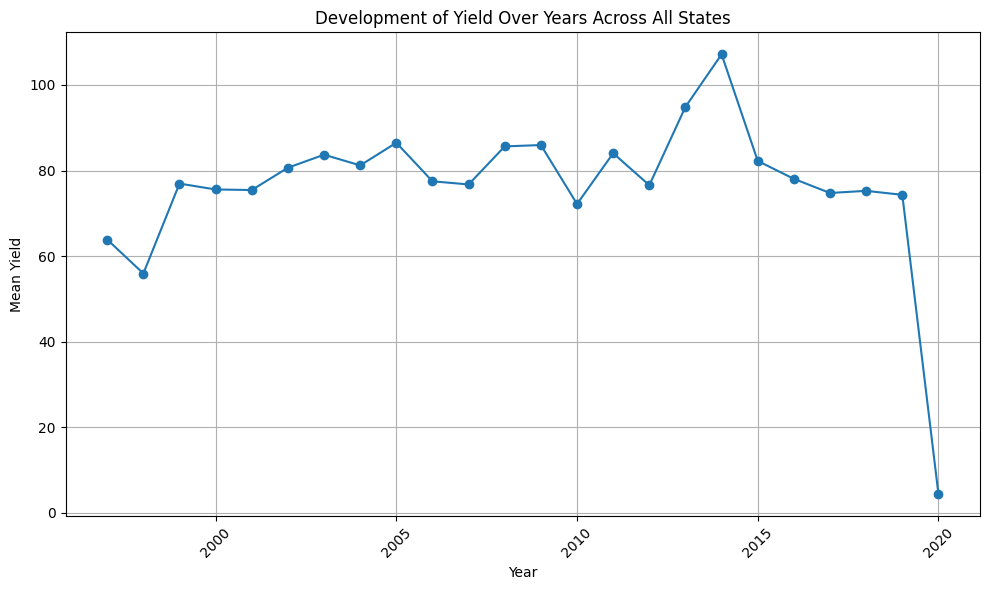

In [13]:
yearly_yield = df.groupby('Crop_Year')['Yield'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_yield['Crop_Year'], yearly_yield['Yield'], marker='o', linestyle='-')
plt.title('Development of Yield Over Years Across All States')
plt.xlabel('Year')
plt.ylabel('Mean Yield')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

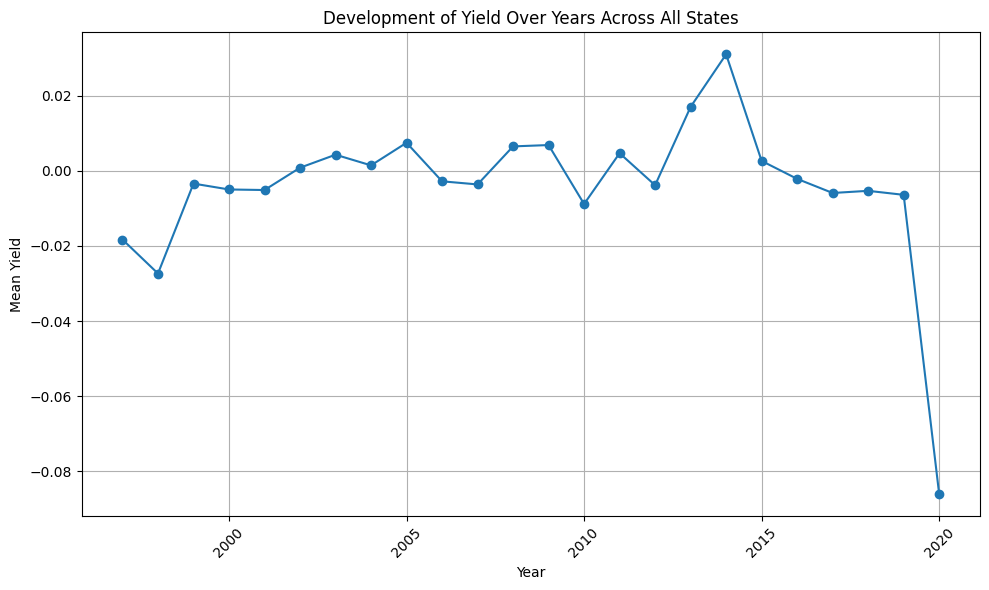

In [14]:
yearly_yield = df.groupby('Crop_Year')['Yield_scaled'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly_yield['Crop_Year'], yearly_yield['Yield_scaled'], marker='o', linestyle='-')
plt.title('Development of Yield Over Years Across All States')
plt.xlabel('Year')
plt.ylabel('Mean Yield')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
features = [ 'Crop_Year_scaled','crop_encoded', 'state_encoded','Area_scaled','Production_scaled','Annual_Rainfall_scaled','Fertilizer_scaled']
target   = [ 'Yield_scaled' ]

X = df.loc[: , features]
Y = df.loc[: , target]

In [17]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size = 0.4,random_state = 20)

In [19]:
X_train_ls = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_ls = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
Y_train_ls  = Y_train.values

print(X_train_ls.shape,X_train_ls[0])

(11813, 1, 7) [[ 0.44205067  4.         19.         -0.24484731 -0.06248026 -0.17279606
  -0.25307566]]


# LSTM MODEL

In [20]:
model = Sequential([
    LSTM(units=100, input_shape=(X_train_ls.shape[1], X_train_ls.shape[2])),
    Dense(units=1)
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_absolute_error')
model.summary()

early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(X_train_ls, Y_train_ls, epochs=150, batch_size=32, validation_split=0.2,
                    callbacks=[early_stopping], verbose=1)

C:\Users\Blossom Academy\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100)                 │          43,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 43,301 (169.14 KB)

 Trainable params: 43,301 (169.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0979 - val_loss: 0.0814
Epoch 2/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0760 - val_loss: 0.0752
Epoch 3/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0697 - val_loss: 0.0708
Epoch 4/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0677 - val_loss: 0.0717
Epoch 5/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0667 - val_loss: 0.0681
Epoch 6/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0666 - val_loss: 0.0660
Epoch 7/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0654 - val_loss: 0.0657
Epoch 8/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0651 - val_loss: 0.0643
Epoch 9/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0646 - val_loss: 0.0649
Epoch 10/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0633 - val_loss: 0.0644
Epoch 11/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0630 - val_loss: 0.0643
Epoch 12/150
296/296 ━━━━━━━━━━━━━━━━━━━━

In [22]:
Y_pred = model.predict(X_test_ls)

mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute Error:", mae)
print("R-squared (R2):", r2)
print("Mean Squared Error:", mse)

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Mean Absolute Error: 0.03787713497877121
R-squared (R2): 0.7488807439804077
Mean Squared Error: 0.25667470693588257


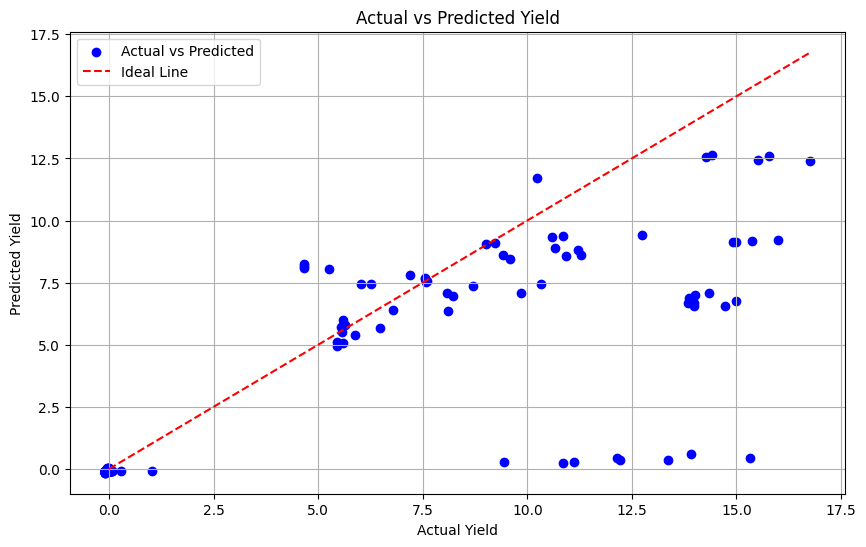

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(Y_test.values, Y_pred, color='blue', label='Actual vs Predicted')

max_val = np.max([np.max(Y_test), np.max(Y_pred)])

plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Ideal Line')

plt.title('Actual vs Predicted Yield')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.legend()
plt.grid(True)
plt.show()

# RNN MODEL

In [26]:
from tensorflow.keras.layers import SimpleRNN, Dense

In [28]:
model_rnn = Sequential([
    SimpleRNN(units=100, input_shape=(X_train_ls.shape[1], X_train_ls.shape[2])),
    Dense(units=1)])

optimizer = Adam(learning_rate=0.001)

model_rnn.compile(optimizer=optimizer, loss='mean_absolute_error')

model_rnn.summary()

early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

history_rnn = model_rnn.fit(X_train_ls,Y_train_ls,epochs=150,batch_size=32,validation_split=0.2,callbacks=[early_stopping],verbose=1)

C:\Users\Blossom Academy\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 100)                 │          10,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,901 (42.58 KB)

 Trainable params: 10,901 (42.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1048 - val_loss: 0.0927
Epoch 2/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0789 - val_loss: 0.0756
Epoch 3/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0750 - val_loss: 0.0888
Epoch 4/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0728 - val_loss: 0.0717
Epoch 5/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0704 - val_loss: 0.0741
Epoch 6/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0696 - val_loss: 0.0683
Epoch 7/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0686 - val_loss: 0.0713
Epoch 8/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0693 - val_loss: 0.0659
Epoch 9/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0659 - val_loss: 0.0636
Epoch 10/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0658 - val_loss: 0.0694
Epoch 11/150
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0666 - val_loss: 0.0650
Epoch 12/150
296/296 ━━━━━━━━━━━━━━━━━━━━

In [29]:
Y_pred_rnn = model_rnn.predict(X_test_ls)

mse = mean_squared_error(Y_test, Y_pred_rnn)
r2 = r2_score(Y_test, Y_pred_rnn)
mae = mean_absolute_error(Y_test, Y_pred_rnn)

print("Mean Absolute Error:", mae)
print("R-squared (R2):", r2)
print("Mean Squared Error:", mse)

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Mean Absolute Error: 0.058334171772003174
R-squared (R2): 0.5894606113433838
Mean Squared Error: 0.41962161660194397


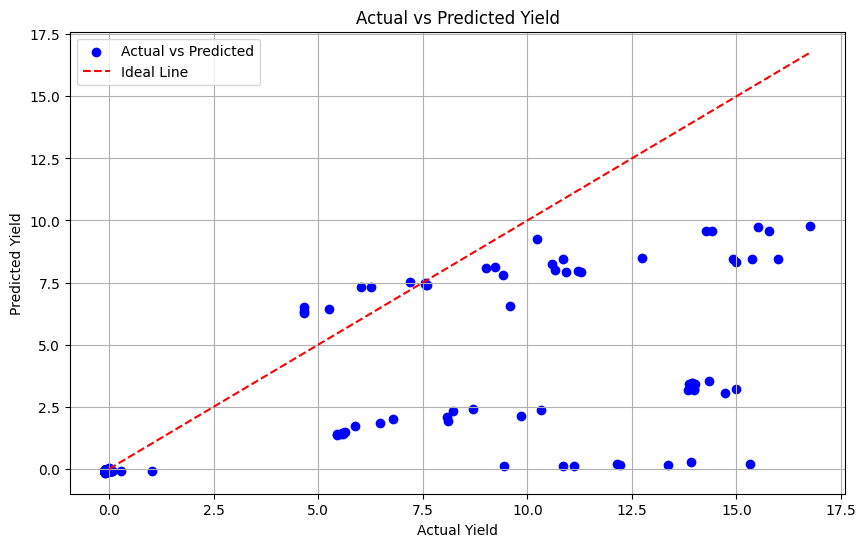

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(Y_test.values, Y_pred_rnn, color='blue', label='Actual vs Predicted')

max_val = np.max([np.max(Y_test), np.max(Y_pred_rnn)])

plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Ideal Line')

plt.title('Actual vs Predicted Yield')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.legend()
plt.grid(True)
plt.show()